In [1]:
# ================================
# Imports
# ================================

import torch
from torchvision import models, transforms
from PIL import Image
import os

In [2]:
# ================================
# Device
# ================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
# ================================
# Load Class Labels
# ================================

# Assuming you have a dataset folder structure: root/train/class_name/images...
from torchvision.datasets import ImageFolder

TRAIN_DIR = "prototype_model/prototype_dataset_splitted/train"                                  ### TO BE CHANGED

train_data = ImageFolder(TRAIN_DIR)
classes = train_data.classes
print(f"Total classes: {len(classes)}")
print("Classes:", classes)

Total classes: 64
Classes: ['Abstract_Animal_Print_Dress', 'Abstract_Asymmetrical_Hem_Top', 'Abstract_Daisy_Print_Blouse', 'Abstract_Dotted_Dress', 'Abstract_Floral_Print_Dress', 'Abstract_Floral_Print_Maxi_Dress', 'Abstract_Grid_Print_Top', 'Abstract_Paisley_Print_Jumpsuit', 'Abstract_Stripe_Top', 'Abstract_V-Cut_Maxi_Dress', 'Abstract_Zippered_Crop_Top', 'Acid_Wash_Denim_Cutoffs', 'Anchor_Print_Shorts', 'Angel-Sleeved_Top', 'Arrow-Printed_Tee', 'Asymmetrical_Chiffon_Skirt', 'Asymmetrical_Pencil_Skirt', 'Bandana_Print_Layered_Tee', 'Barbie_Tank_Top', 'Baroque_Print_Crop_Top', 'Basic_V-Neck_Tee', 'Bell-Sleeved_Lace_Dress', 'Belted_Floral_Print_Dress', 'Big_Apples_Tee', 'Bird_Print_Kimono', 'Blah_Blah_Blah_Tee', 'Bleached_Denim_Jacket', 'Bleached_Low-Rise_Skinny_Jeans', 'Bob_Dylan_Graphic_Tee', 'Botanical_Print_Fit_&_Flare_Dress', 'Boxy_Faux_Fur_Jacket', 'Boyz_II_Men_Muscle_Tee', 'Brooklyn_Nets_Baseball_Tee', 'Brooklyn_Nets_Logo_Hoodie', 'Brooklyn_Nets_Logo_Sweatpants', 'Button-Down_Den

In [4]:
# ================================
# Model Setup
# ================================

NUM_CLASSES = 64                                                                                ### TO BE CHANGED
MODEL_PATH = "prototype_model/prototype_trained_models/resnet50_20251116_162404/dress_type_model_epoch_32_acc_99.84.pth"          ### TO BE CHANGED

# Load ResNet50
model = models.resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()
print("Model loaded:", MODEL_PATH)

Model loaded: prototype_model/prototype_trained_models/resnet50_20251116_162404/dress_type_model_epoch_32_acc_99.84.pth


In [5]:
# ================================
# Image Transform
# ================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [6]:
# ================================
# Load Test Image
# ================================

####
#   Abstract_Daisy_Print_Blouse_Test.png
#   Abstract_Floral_Print_Maxi_Dress_Test.png
#   Anchor_Print_Shorts_Test.png
#   Bleached_Denim_Jacket_Test.png
#   Brooklyn_Nets_Baseball_Tee_Test.png
#   Cheetah_Print_High_Neck_Blouse_Test.png
#   Daisy_Print_Maxi_Skirt_Test.png
#   Slim_Fit_Moto_Jeans_Test.png
####

TEST_DIR = "test_images"                                                                        ### TO BE CHANGED
IMAGE_PATH = f"{TEST_DIR}/Abstract_Daisy_Print_Blouse_Test.png"                                       ### TO BE CHANGED

img = Image.open(IMAGE_PATH).convert("RGB")
inp = transform(img).unsqueeze(0).to(device)  # Add batch dimension

In [7]:
# ================================
# Inference
# ================================

with torch.no_grad():
    output = model(inp)
    _, pred = torch.max(output, 1)

pred_class = classes[pred.item()]
print(f"Predicted Dress Type: {pred_class}")

Predicted Dress Type: Abstract_Daisy_Print_Blouse


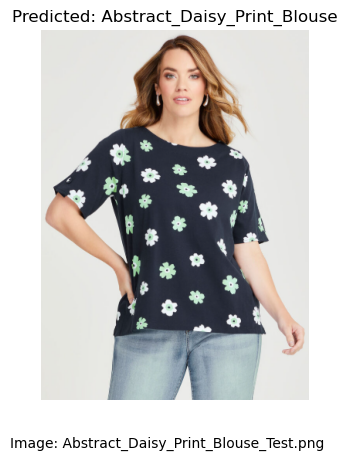

In [8]:
# ================================
# Show Image
# ================================

import matplotlib.pyplot as plt

image_name = os.path.basename(IMAGE_PATH)

plt.imshow(img)
plt.title(f"Predicted: {pred_class}")
plt.figtext(0.5, 0.01, f"Image: {image_name}", ha="center")
plt.axis("off")
plt.show()